In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import train_test_split

In [ ]:
iris = load_iris()
features = iris.data
data = pd.DataFrame(features, columns=iris.feature_names)

X = data.iloc[:, [0, 2]]
y = iris.target

1. Постройте последний график методических указаний в исходном пространстве признаков.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


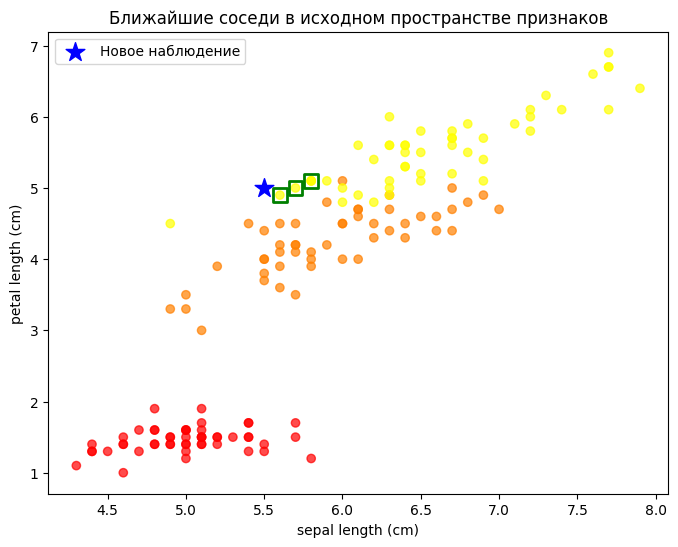

In [ ]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_scaled, y)

observation_new = [[5.5, 5]]
observation_new_scaled = scaler.transform(observation_new)
distances, indices = knn.kneighbors(observation_new_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, cmap='autumn', alpha=0.7)
plt.scatter(observation_new[0][0], observation_new[0][1], marker='*', s=200, color='blue', label='Новое наблюдение')

for i in indices[0]:
    plt.scatter(X.iloc[i, 0], X.iloc[i, 1], marker='s', s=100, edgecolors='green', facecolors='none', linewidth=2)

plt.xlabel('sepal length (cm)')
plt.ylabel('petal length (cm)')
plt.title('Ближайшие соседи в исходном пространстве признаков')
plt.legend()
plt.show()

2. Попробуйте обучить модель с другим значением k. Визуализируйте области классификации и сравните эффективности модели.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


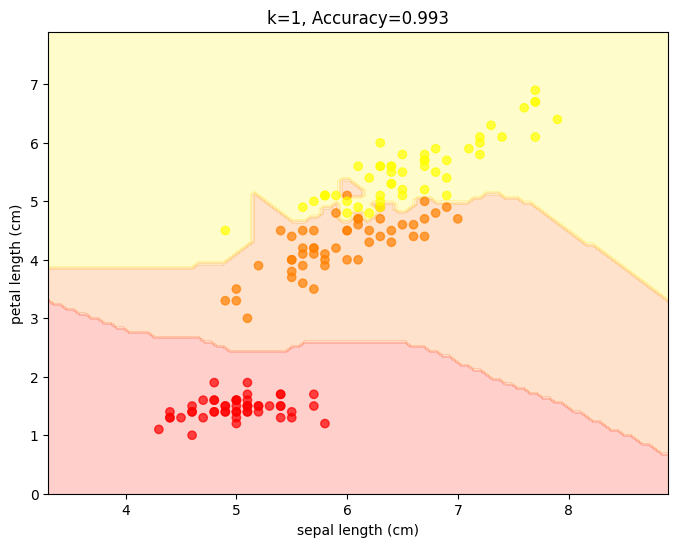

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


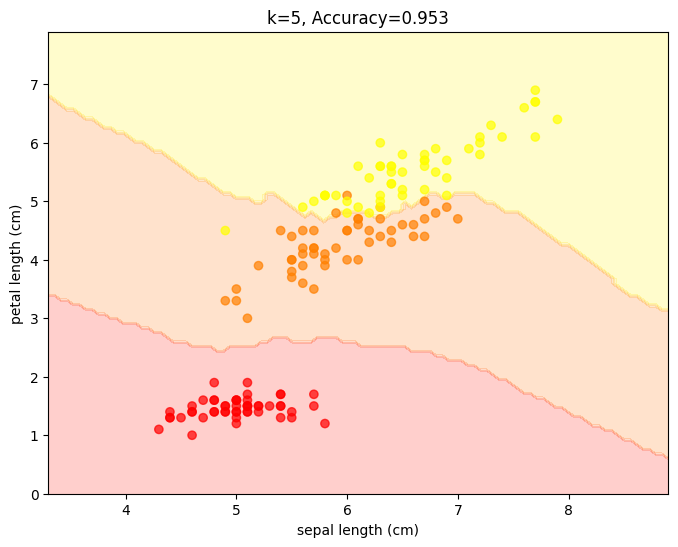

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


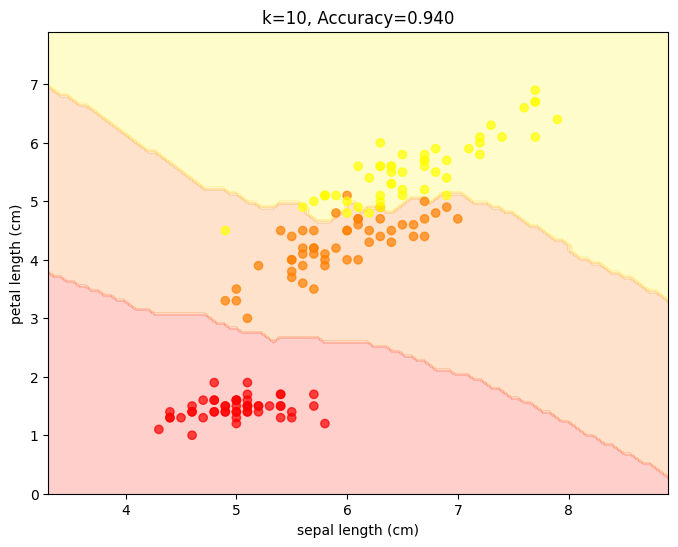

In [ ]:
k_values = [1, 5, 10]
for k in k_values:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_scaled, y)
    y_pred = knn_k.predict(X_scaled)
    acc = accuracy_score(y, y_pred)

    X0 = np.linspace(X.iloc[:, 0].min()-1, X.iloc[:, 0].max()+1, 100)
    X1 = np.linspace(X.iloc[:, 1].min()-1, X.iloc[:, 1].max()+1, 100)
    X0_grid, X1_grid = np.meshgrid(X0, X1)
    XX = np.array([X0_grid.ravel(), X1_grid.ravel()]).T
    XX_scaled = scaler.transform(XX)
    Z = knn_k.predict(XX_scaled).reshape(X0_grid.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(X0_grid, X1_grid, Z, cmap='autumn', alpha=0.2)
    plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, cmap='autumn', alpha=0.7)
    plt.xlabel('sepal length (cm)')
    plt.ylabel('petal length (cm)')
    plt.title(f'k={k}, Accuracy={acc:.3f}')
    plt.show()

3. Подвигайте новое наблюдение в последнем пункте методических указаний. Сдвиньте его за пределы области определения выборки. Как меняется нормализованное значение?

In [ ]:
test_points = [[5.5, 5], [10, 10], [1, 1], [0, 0]]
for point in test_points:
    scaled_point = scaler.transform([point])
    print(f"Исходная точка: {point}, Нормализованная: {scaled_point[0]}")

Исходная точка: [5.5, 5], Нормализованная: [0.33333333 0.6779661 ]
Исходная точка: [10, 10], Нормализованная: [1.58333333 1.52542373]
Исходная точка: [1, 1], Нормализованная: [-0.91666667  0.        ]
Исходная точка: [0, 0], Нормализованная: [-1.19444444 -0.16949153]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


4. Поэкспериментируйте с разными метриками расстояния. Визуализируйте ближайших соседей нового объекта при разных метриках расстояния.

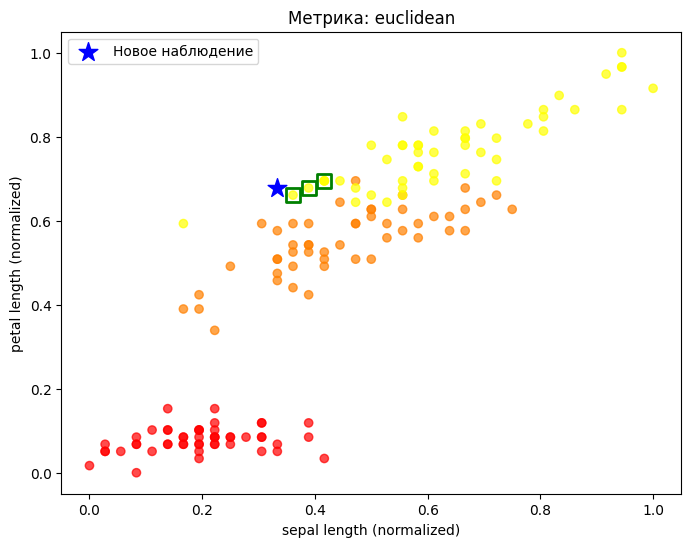

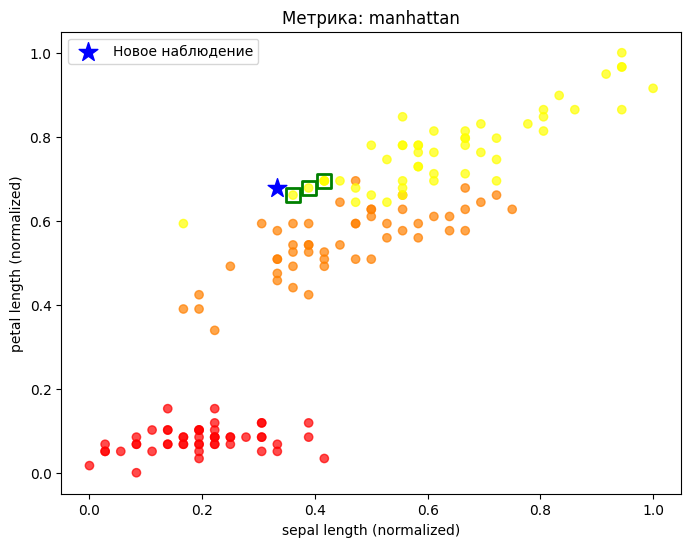

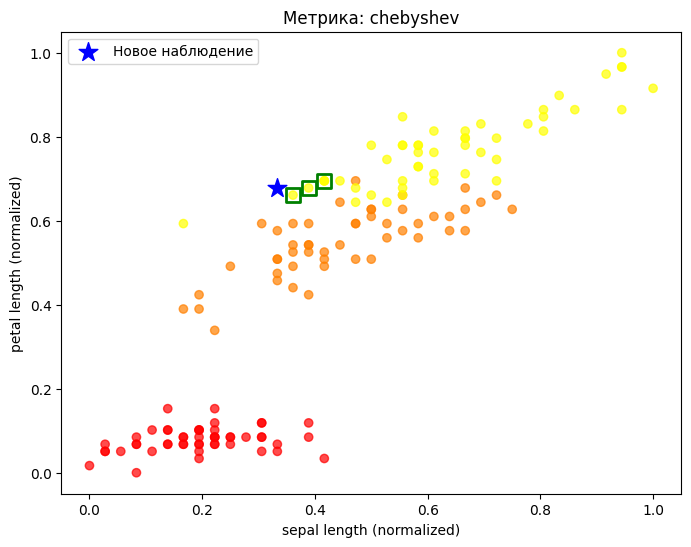

In [ ]:
metrics = ['euclidean', 'manhattan', 'chebyshev']
for metric in metrics:
    knn_metric = KNeighborsClassifier(n_neighbors=3, metric=metric)
    knn_metric.fit(X_scaled, y)
    distances, indices = knn_metric.kneighbors(observation_new_scaled)

    plt.figure(figsize=(8, 6))
    plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap='autumn', alpha=0.7)
    plt.scatter(observation_new_scaled[0][0], observation_new_scaled[0][1],
                marker='*', s=200, color='blue', label='Новое наблюдение')

    for i in indices[0]:
        plt.scatter(X_scaled[i, 0], X_scaled[i, 1], marker='s', s=100,
                   edgecolors='green', facecolors='none', linewidth=2)

    plt.xlabel('sepal length (normalized)')
    plt.ylabel('petal length (normalized)')
    plt.title(f'Метрика: {metric}')
    plt.legend()
    plt.show()

5. Обучите модель на полном датасете. Сравните ее эффективность с описанной в методических указаниях. Попробуйте разные значения k.

In [ ]:
X_full = iris.data
scaler_full = MinMaxScaler()
X_full_scaled = scaler_full.fit_transform(X_full)

k_values = [1, 3, 5, 7, 9, 11]
for k in k_values:
    knn_full = KNeighborsClassifier(n_neighbors=k)
    knn_full.fit(X_full_scaled, y)
    y_pred_full = knn_full.predict(X_full_scaled)
    acc_full = accuracy_score(y, y_pred_full)
    print(f'k={k}, Accuracy на полном датасете: {acc_full:.3f}')

k=1, Accuracy на полном датасете: 1.000
k=3, Accuracy на полном датасете: 0.967
k=5, Accuracy на полном датасете: 0.960
k=7, Accuracy на полном датасете: 0.967
k=9, Accuracy на полном датасете: 0.973
k=11, Accuracy на полном датасете: 0.960


6. Попробуйте в модели на полном датасете взвешенный алгоритм (аргумент weights объекта KNeighborsClassifier). Сравние его точность с равномерным вариантом.

In [ ]:
knn_uniform = KNeighborsClassifier(n_neighbors=5, weights='uniform')
knn_distance = KNeighborsClassifier(n_neighbors=5, weights='distance')

knn_uniform.fit(X_full_scaled, y)
knn_distance.fit(X_full_scaled, y)

y_pred_uniform = knn_uniform.predict(X_full_scaled)
y_pred_distance = knn_distance.predict(X_full_scaled)

acc_uniform = accuracy_score(y, y_pred_uniform)
acc_distance = accuracy_score(y, y_pred_distance)

print(f'Uniform weights accuracy: {acc_uniform:.3f}')
print(f'Distance weights accuracy: {acc_distance:.3f}')

Uniform weights accuracy: 0.960
Distance weights accuracy: 1.000


7. Постройте график точности (accuracy) модели в зависимости от значения k. Сделайте вывод.

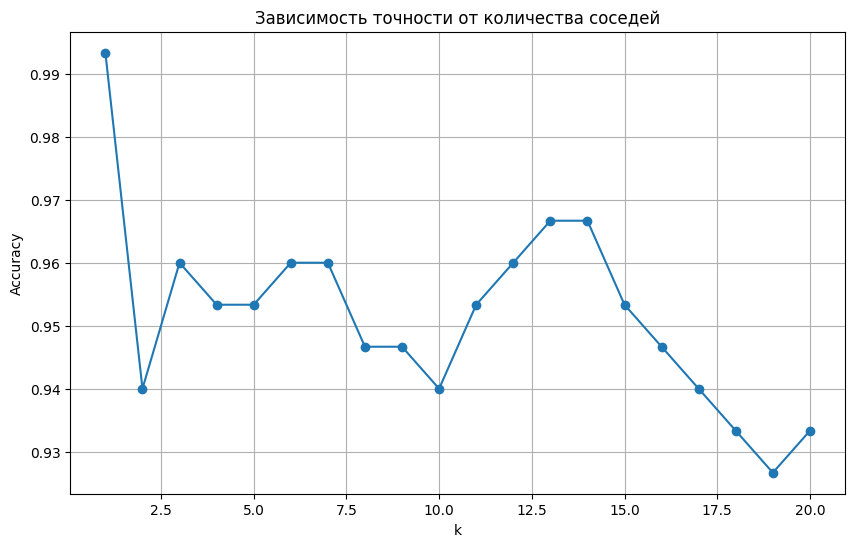

In [ ]:
accuracies = []
k_range = range(1, 21)

for k in k_range:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_scaled, y)
    y_pred_temp = knn_temp.predict(X_scaled)
    accuracies.append(accuracy_score(y, y_pred_temp))

plt.figure(figsize=(10, 6))
plt.plot(k_range, accuracies, marker='o')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.title('Зависимость точности от количества соседей')
plt.grid(True)
plt.show()

8. Выберите датасет и постройте регрессию при помощи метода ближайших соседей.

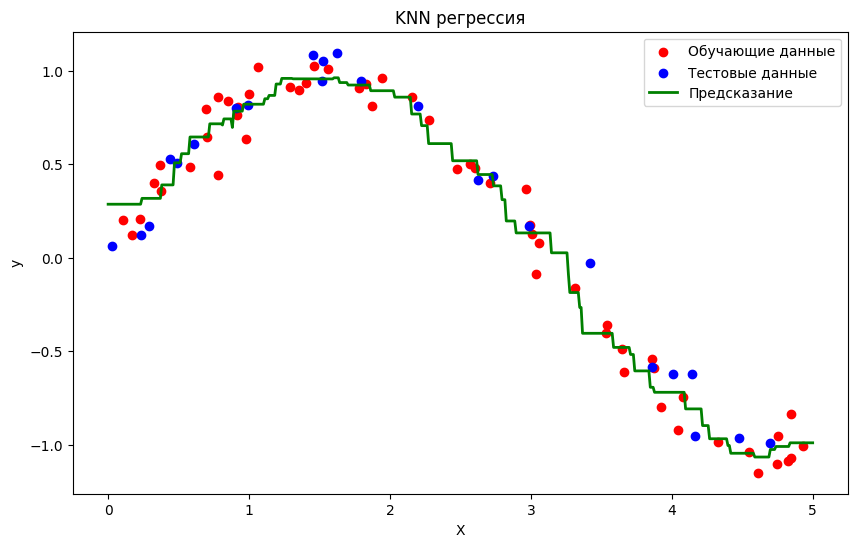

MSE регрессии: 0.0164


In [ ]:
np.random.seed(42)
X_reg = np.sort(5 * np.random.rand(80, 1), axis=0)
y_reg = np.sin(X_reg).ravel() + np.random.normal(0, 0.1, X_reg.shape[0])

X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.3, random_state=42)

knn_reg = KNeighborsRegressor(n_neighbors=5)
knn_reg.fit(X_train, y_train)
y_pred_reg = knn_reg.predict(X_test)

plt.figure(figsize=(10, 6))
X_plot = np.linspace(0, 5, 500)[:, np.newaxis]
y_plot = knn_reg.predict(X_plot)

plt.scatter(X_train, y_train, color='red', label='Обучающие данные')
plt.scatter(X_test, y_test, color='blue', label='Тестовые данные')
plt.plot(X_plot, y_plot, color='green', linewidth=2, label='Предсказание')
plt.xlabel('X')
plt.ylabel('y')
plt.title('KNN регрессия')
plt.legend()
plt.show()

mse = np.mean((y_test - y_pred_reg) ** 2)
print(f'MSE регрессии: {mse:.4f}')